In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [17]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [18]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [19]:
alpha_beta = perf[
    ["amfi_code", "scheme_name", "alpha", "beta"]
]

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [20]:
scorecard = perf.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(pct=True)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["alpha_rank"] = scorecard["alpha"].rank(pct=True)

scorecard["expense_rank"] = (
    -scorecard["expense_ratio_pct"]
).rank(pct=True)

scorecard["dd_rank"] = (
    -scorecard["max_drawdown_pct"]
).rank(pct=True)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 30 +
    scorecard["sharpe_rank"] * 25 +
    scorecard["alpha_rank"] * 20 +
    scorecard["expense_rank"] * 15 +
    scorecard["dd_rank"] * 10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,0.975,0.5375,0.4625,0.8875,0.750,72.750
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,0.750,0.7250,0.9375,0.4750,0.500,71.500
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,0.850,0.6500,0.9750,0.2000,0.625,70.500
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,0.950,0.4125,0.9000,0.3125,0.675,68.250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.000,0.5750,0.5250,0.5000,0.200,64.375


In [21]:
scorecard = perf.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(pct=True)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["alpha_rank"] = scorecard["alpha"].rank(pct=True)

scorecard["expense_rank"] = (
    -scorecard["expense_ratio_pct"]
).rank(pct=True)

scorecard["dd_rank"] = (
    -scorecard["max_drawdown_pct"]
).rank(pct=True)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 30 +
    scorecard["sharpe_rank"] * 25 +
    scorecard["alpha_rank"] * 20 +
    scorecard["expense_rank"] * 15 +
    scorecard["dd_rank"] * 10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,0.975,0.5375,0.4625,0.8875,0.750,72.750
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,0.750,0.7250,0.9375,0.4750,0.500,71.500
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,0.850,0.6500,0.9750,0.2000,0.625,70.500
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,0.950,0.4125,0.9000,0.3125,0.675,68.250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.000,0.5750,0.5250,0.5000,0.200,64.375


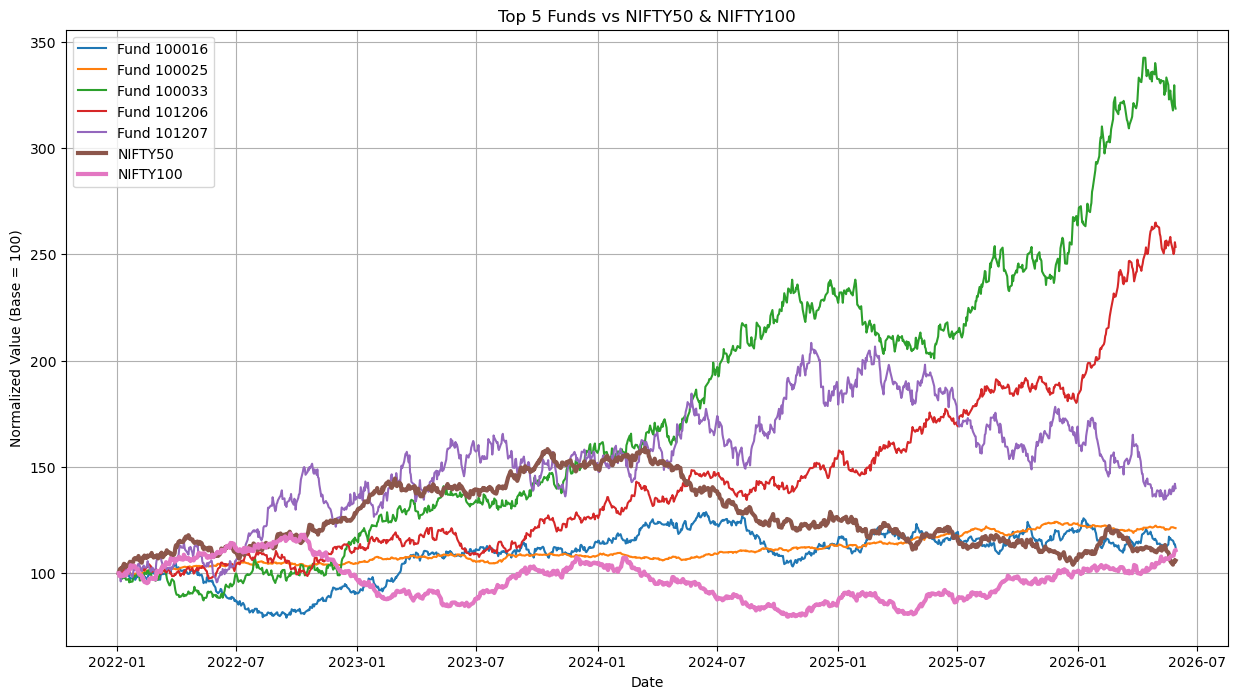

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])

# First 5 funds
top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(15,8))

for code in top5:
    temp = nav[nav["amfi_code"] == code].copy()
    temp = temp.sort_values("date")

    if len(temp) > 0:
        normalized = (
            temp["nav"] /
            temp["nav"].iloc[0]
        ) * 100

        plt.plot(
            temp["date"],
            normalized,
            label=f"Fund {code}"
        )

# NIFTY50
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")

nifty50_norm = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50_norm,
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100_norm = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100_norm,
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
pd.read_csv("../reports/alpha_beta.csv").shape
pd.read_csv("../reports/fund_scorecard.csv").shape

(40, 25)